In [1]:
import pandas as pd
import numpy as np
from ScanImageTiffReader import ScanImageTiffReader
import os
import matplotlib.pyplot as plt
import scipy.signal
import tifffile
from scipy.signal import butter, lfilter,find_peaks, gaussian, convolve
from ibllib.io.video import *
import scipy.ndimage
import cv2
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from matplotlib.animation import PillowWriter
from ScanImageTiffReader import ScanImageTiffReader
import json
import ast
from murphlib.caimage import *
from murphlib.tools import *
from murphlib.plotting import *
from murphlib.regression import *
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score
from scipy.stats import zscore

plt.rcParams['animation.ffmpeg_path'] = r'D:\ffmpeg\bin\ffmpeg.exe'

In [2]:
path = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\AD_L2\20250523_pc'

In [3]:
subdir = [d for d in os.listdir(path)]
print('processing '+path)
if 'arm1' in subdir:
    arm1_img_path = os.path.join(path, 'arm1')
    try: 
        with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
            arm1_img_meta = json.load(json_file)
    except:
        raw_img_path = find_tif_file(arm1_img_path)
        reader=ScanImageTiffReader(raw_img_path)
        arm1_img_meta = parse_text_to_dict(reader.metadata())
        with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'w') as json_file:
            json.dump(arm1_img_meta, json_file)
    arm1_suite2p_path = os.path.join(arm1_img_path,'suite2p','plane0')
    arm1_fluo = np.load(arm1_suite2p_path+'\\F.npy', allow_pickle=True)
    arm1_neufluo = np.load(arm1_suite2p_path+'\\Fneu.npy', allow_pickle=True)
    raw_arm1_stat = np.load(arm1_suite2p_path+'\\stat.npy', allow_pickle=True)
    arm1_iscell = np.load(arm1_suite2p_path+'\\iscell.npy', allow_pickle=True)
    arm1_iscell = arm1_iscell[:,0]==1
    arm1_stat = []
    for i, s in enumerate(raw_arm1_stat):
        if arm1_iscell[i]:
            s['id'] = i
            arm1_stat.append(s)
    arm1_fluo = arm1_fluo[arm1_iscell,:]
    arm1_neufluo = arm1_neufluo[arm1_iscell,:]
    frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
    # try:
    #     arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile.npy'))
    # except:
    #     arm1_dff = calculate_dff_with_moving_percentile_vectorized(arm1_fluo, frame_rate=frame_rate_arm1, moving_window=20, percentile=10)
    #     #### only do this if front need to be padded
    #     #arm1_dff = np.hstack([np.zeros((arm1_dff.shape[0],30)), arm1_dff])
    #     np.save(os.path.join(arm1_img_path, 'dff_moving_percentile.npy'), arm1_dff)

    # arm1_aspect_ratio = np.array([arm1_stat[i]['aspect_ratio'] for i in range(len(arm1_stat))])
    # arm1_npix = np.array([arm1_stat[i]['npix'] for i in range(len(arm1_stat))])
    # arm1_pc_idx = np.where((arm1_aspect_ratio<1.1) & (arm1_npix<120) & (arm1_npix>100))[0]
    # arm1_dd_idx = np.where((arm1_aspect_ratio>1.1) | (arm1_npix>120) | (arm1_npix<100))[0]
    # arm1_pc_suite2p_idx = np.array([arm1_stat[i]['id'] for i in arm1_pc_idx])
    # arm1_dd_suite2p_idx = np.array([arm1_stat[i]['id'] for i in arm1_dd_idx])

    # try:
    #     arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))
    # except:
    #     lp_arm1_dff = arm1_dff.copy()
    #     if len(arm1_pc_idx) != 0:
    #         arm1_pc_dff = calculate_dff_with_moving_percentile_vectorized(arm1_fluo[arm1_pc_idx], frame_rate=frame_rate_arm1, moving_window=60, percentile=50)
    #         lp_arm1_dff[arm1_pc_idx] = arm1_pc_dff
    #     lp_arm1_dff[arm1_pc_idx] = butter_filter(lp_arm1_dff[arm1_pc_idx], cutoff=0.5, fs=frame_rate_arm1, filter_type='low', order=5)
    #     np.save(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'), lp_arm1_dff)

processing Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\AD_L2\20250523_pc


In [4]:
arm1_ops = np.load(arm1_suite2p_path+'\\ops.npy', allow_pickle=True).item()

In [5]:
arm1_zstackmean_tiff_file = find_tif_file(os.path.join(arm1_img_path, 'zstack'))
arm1_zstackmean_tiff_file = [f for f in arm1_zstackmean_tiff_file if 'zstackmean' in f][0]
arm1_zstackmean = load_tif_file(arm1_zstackmean_tiff_file)
arm1_zstackmean = np.array(arm1_zstackmean)

In [6]:
arm1_zplanes = np.argmax(arm1_ops['zcorr'], axis=0)

In [8]:
arm1_zstack_fluo = calculate_zstack_fluo(arm1_stat, arm1_zstackmean)


In [9]:
arm1_zcorrect_fluo = calculate_zshift_corrected_fluo(arm1_fluo, arm1_zstack_fluo, arm1_zplanes)

arm1_zcorrect_fluo.shape






(432, 45569)

In [10]:
arm1_fluo.shape


(432, 45569)

In [11]:
arm1_aspect_ratio = np.array([arm1_stat[i]['aspect_ratio'] for i in range(len(arm1_stat))])
arm1_npix = np.array([arm1_stat[i]['npix'] for i in range(len(arm1_stat))])
arm1_pc_idx = np.where((arm1_aspect_ratio<1.1) & (arm1_npix<120) & (arm1_npix>100))[0]
arm1_dd_idx = np.where((arm1_aspect_ratio>1.1) | (arm1_npix>120) | (arm1_npix<100))[0]
arm1_pc_suite2p_idx = np.array([arm1_stat[i]['id'] for i in arm1_pc_idx])
arm1_dd_suite2p_idx = np.array([arm1_stat[i]['id'] for i in arm1_dd_idx])

In [19]:
arm1_pc_idx

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  23,  24,  25,  26,  27,
        28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,
        41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 174, 175, 176], dtype=int64)

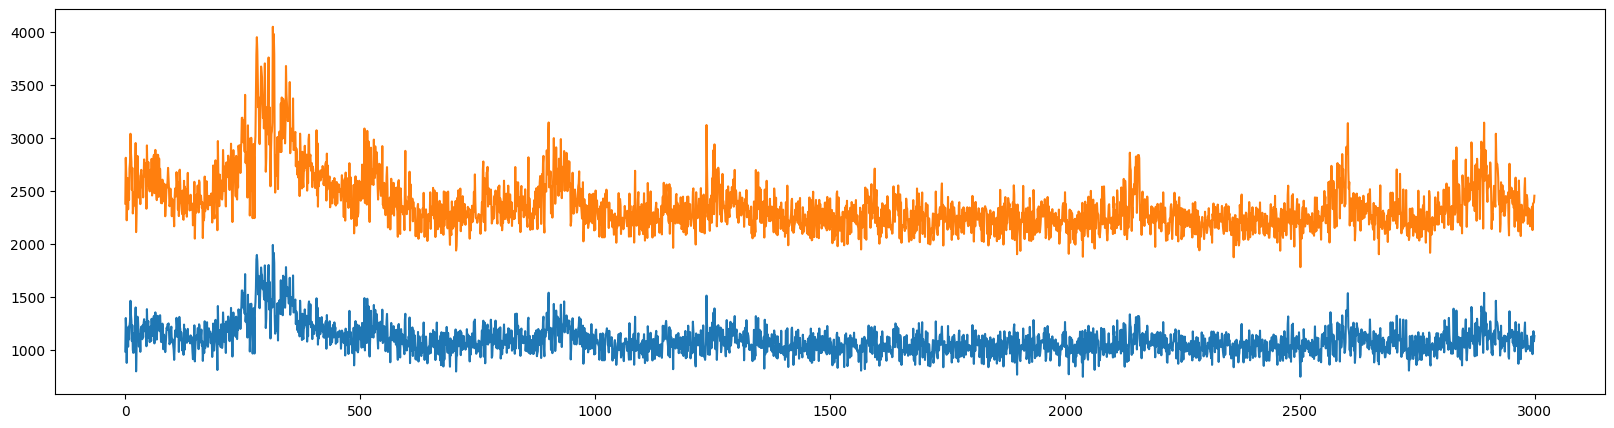

In [27]:
suite2p_idx = 88
timepoints = np.arange(27000, 30000)
plt.figure(figsize=(20,5))
plt.plot(arm1_fluo[arm1_pc_idx[np.where(arm1_pc_suite2p_idx==suite2p_idx)[0][0]],timepoints])
plt.plot(arm1_zcorrect_fluo[arm1_pc_idx[np.where(arm1_pc_suite2p_idx==suite2p_idx)[0][0]],timepoints]+1000)
plt.show()




